In [13]:
#@title General Imports

# system tools
import os
import time
import shutil
import subprocess
from pathlib import Path
import tempfile
import zipfile
import warnings
# Mute only this ArviZ FutureWarning message 
# We have pinned corner and emcee versions to avoid this becoming an issue
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"arviz(\.|$)",
    message=r".*ArviZ is undergoing a major refactor.*",
)
# data analysis tools
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display
import pandas as pd
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from scipy.optimize import approx_fprime
import emcee
import corner
import astropy.units as u
from astropy.coordinates import SkyCoord
try:
    from google.colab import sheets  # this will only work if you are running on Colab
except:
    pass

# web scrapping tools
import requests

In [2]:
#@title Cloning the GitHub repository
if not os.path.exists("data-challenge-1"):

    # Clone
    !printf "🐑 " && git clone --depth 1 https://github.com/microlensing-data-challenge/data-challenge-1.git
else:
    print("ℹ️ data-challenge-1 already exists; skipping clone")

if not os.path.exists("data-challenge-1/lc"):
    # Extract with lightweight progress dots every N checkpoints
    print("\n🗃️ Extracting files")
    # extract with progress dots, if supported
    try:
        subprocess.run(["tar", "-xzf", "data-challenge-1/lc.tar.gz", "-C",
                        "data-challenge-1/", "--checkpoint=1000",
                        "--checkpoint-action=dot"], check=True)
    except:
        subprocess.run(["tar", "-xzf", "data-challenge-1/lc.tar.gz",
                        "-C", "data-challenge-1/"], check=True)

print("\n✅ Lightcurve files are ready.")

ℹ️ data-challenge-1 already exists; skipping clone

✅ Lightcurve files are ready.


In [16]:
master_file = './data-challenge-1/Answers/master_file.txt'
header_file = './data-challenge-1/Answers/wfirstColumnNumbers.txt'

rows = []
with open(master_file, "r") as f:
    for line in f:
        line = line.strip()
        # Skip empty lines or comment lines
        if not line or line.startswith("#"):
            continue

        tokens = line.split()  # split on whitespace
        # Planets: omcassan; binary lens: ombin
        if "ombin" not in tokens:
            continue

        # Single-lens lines should have exactly 96 columns
        #if len(tokens) != 82:
            #continue
        
        rows.append(tokens)
        
df_bl = pd.DataFrame(rows)

# For binary star lenses and bound planets they are:
# 72 - unimportant
# 73 - Delta chi^2 (relative to a flat line)
# 74 - unimportant
# 75 - Delta chi^2 (relative to a single lens fit PSPL or FSPL if necessary)
# 76 - |
# 77 - unimportant
# 78 - simulated event type (ombin = Binary star, omcassan = Bound planet) 
# 79 - unimportant (I think)
# 80 - lightcurve filename root
# 81 - Data challenge lightcurve number

# make an array of zeros with 82 elements
colnames_82 = np.zeros(82, dtype=object)

# Read the header file
with open(header_file, 'r') as f:
    for i, line in enumerate(f):
        if i >= 82:  # Only read the first 82 lines for the binary lens events
            break
        line = line.strip()
        # Skip empty lines or comments
        if not line or line.startswith('#'):
            continue
        # The second token is the 'name'
        parts = line.split()
        colnames_82[int(parts[0])] = parts[1]
        
# Replace the column names in colnames_82
colnames_82[73] = 'Delta chi2 flat'
colnames_82[75] = 'Delta chi2 single lens'
colnames_82[78] = 'sim type'
colnames_82[80] = 'filename'
colnames_82[81] = 'lc_number'

# Make sure the column names are unique
for i in range(82):
    if colnames_82[i] == '|' or colnames_82[i] == 0:
        colnames_82[i] = 'col_' + str(i)

# Replace the column names in the data_frame
df_bl.columns = colnames_82

# Remove the dummy columns 'col_*'
df_bl = df_bl.loc[:, ~df_bl.columns.str.startswith('col_')]


In [17]:
lc_number_bl = df_bl['lc_number'].to_numpy()
lc_file_path_format = 'data-challenge-1/lc/ulwdc1_XXX_filter.txt'
lc_file_paths_W149_bl = [lc_file_path_format.replace('filter', 'W149')] * len(lc_number_bl)
lc_file_paths_Z087_bl = [lc_file_path_format.replace('filter', 'Z087')] * len(lc_number_bl)
lc_file_paths_W149_bl = [path.replace('XXX', str(num).zfill(3)) for path, num in zip(lc_file_paths_W149_bl, lc_number_bl)]
lc_file_paths_Z087_bl = [path.replace('XXX', str(num).zfill(3)) for path, num in zip(lc_file_paths_Z087_bl, lc_number_bl)]
df_bl['lc_file_path_W149'] = lc_file_paths_W149_bl
df_bl['lc_file_path_Z087'] = lc_file_paths_Z087_bl
df_bl

,idx,subrun,field,l,b,ra,dec,src_id,Ds,Rs,...,Delta chi2 flat,chi2_1,Delta chi2 single lens,normw,sim type,sigma_tE,filename,lc_number,lc_file_path_W149,lc_file_path_Z087
0,18,0,52,0.489318,-3.30021,269.959,-30.1918,3356,10.572,0.999,...,88076.6,0,348.477,|,ombin,0.462222,ombin_0_52_18,2,data-challenge-1/lc/ulwdc1_002_W149.txt,data-challenge-1/lc/ulwdc1_002_Z087.txt
1,2,0,88,1.1106,-0.604929,267.649,-28.2978,13758,8.368,0.212,...,510389,1,19601.1,|,ombin,0.904826,ombin_0_88_2,6,data-challenge-1/lc/ulwdc1_006_W149.txt,data-challenge-1/lc/ulwdc1_006_Z087.txt
2,13,0,33,0.182555,-1.52365,268.01,-29.5647,4661,11.684,1.37,...,9.53734e+07,0,13811.2,|,ombin,0.243043,ombin_0_33_13,9,data-challenge-1/lc/ulwdc1_009_W149.txt,data-challenge-1/lc/ulwdc1_009_Z087.txt
3,488,0,73,0.738321,-1.21338,268.028,-28.9286,18445,9.426,0.328,...,314650,0,88887.5,|,ombin,0.760807,ombin_0_73_488,14,data-challenge-1/lc/ulwdc1_014_W149.txt,data-challenge-1/lc/ulwdc1_014_Z087.txt
4,308,0,33,0.029591,-1.47442,267.871,-29.6712,4672,11.858,1.78,...,8.53256e+06,0,2.54374e+06,|,ombin,0.271423,ombin_0_33_308,18,data-challenge-1/lc/ulwdc1_018_W149.txt,data-challenge-1/lc/ulwdc1_018_Z087.txt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,132,0,34,0.186163,-1.29566,267.786,-29.4453,17762,9.352,0.439,...,7.36682e+06,0,1.60917e+06,|,ombin,0.28603,ombin_0_34_132,282,data-challenge-1/lc/ulwdc1_282_W149.txt,data-challenge-1/lc/ulwdc1_282_Z087.txt
79,244,0,3,-0.451467,-2.36586,268.476,-30.5381,9324,7.957,0.439,...,25750,0,24964.6,|,ombin,0.184709,ombin_0_3_244,283,data-challenge-1/lc/ulwdc1_283_W149.txt,data-challenge-1/lc/ulwdc1_283_Z087.txt
80,267,0,32,0.0449139,-1.78103,268.184,-29.8141,8899,7.203,0.254,...,73475.7,0,1930.21,|,ombin,0.237367,ombin_0_32_267,284,data-challenge-1/lc/ulwdc1_284_W149.txt,data-challenge-1/lc/ulwdc1_284_Z087.txt
81,425,0,91,1.22851,-3.31718,270.396,-29.5583,441,5.96,0.891,...,160301,0,52945,|,ombin,0.952624,ombin_0_91_425,287,data-challenge-1/lc/ulwdc1_287_W149.txt,data-challenge-1/lc/ulwdc1_287_Z087.txt


In [18]:
header = ["Event_name",
          "Event_number",
          "RA_(deg)",
          "Dec_(deg)",
          "Distance",
          "A_W149",
          "sigma_A_W149",
          "A_Z087",
          "sigma_A_Z087"
]
event_info_bl = pd.read_csv('./data-challenge-1/event_info.txt', names=header, sep='\s+')
merged_bl_df = pd.merge(event_info_bl, df_bl.astype({'lc_number': 'int64'}), left_on='Event_number', right_on='lc_number', how='inner')
merged_bl_df

,Event_name,Event_number,RA_(deg),Dec_(deg),Distance,A_W149,sigma_A_W149,A_Z087,sigma_A_Z087,idx,...,Delta chi2 flat,chi2_1,Delta chi2 single lens,normw,sim type,sigma_tE,filename,lc_number,lc_file_path_W149,lc_file_path_Z087
0,ulwdc1_002,2,269.959,-30.1918,8.09,0.49,0.01,0.95,0.01,18,...,88076.6,0,348.477,|,ombin,0.462222,ombin_0_52_18,2,data-challenge-1/lc/ulwdc1_002_W149.txt,data-challenge-1/lc/ulwdc1_002_Z087.txt
1,ulwdc1_006,6,267.649,-28.2978,8.29,1.64,0.15,3.15,0.30,2,...,510389,1,19601.1,|,ombin,0.904826,ombin_0_88_2,6,data-challenge-1/lc/ulwdc1_006_W149.txt,data-challenge-1/lc/ulwdc1_006_Z087.txt
2,ulwdc1_009,9,268.010,-29.5647,8.47,0.96,0.02,1.85,0.04,13,...,9.53734e+07,0,13811.2,|,ombin,0.243043,ombin_0_33_13,9,data-challenge-1/lc/ulwdc1_009_W149.txt,data-challenge-1/lc/ulwdc1_009_Z087.txt
3,ulwdc1_014,14,268.028,-28.9286,8.21,1.10,0.01,2.11,0.02,488,...,314650,0,88887.5,|,ombin,0.760807,ombin_0_73_488,14,data-challenge-1/lc/ulwdc1_014_W149.txt,data-challenge-1/lc/ulwdc1_014_Z087.txt
4,ulwdc1_018,18,267.871,-29.6712,8.47,0.96,0.02,1.85,0.04,308,...,8.53256e+06,0,2.54374e+06,|,ombin,0.271423,ombin_0_33_308,18,data-challenge-1/lc/ulwdc1_018_W149.txt,data-challenge-1/lc/ulwdc1_018_Z087.txt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,ulwdc1_282,282,267.786,-29.4453,8.41,1.33,0.04,2.56,0.08,132,...,7.36682e+06,0,1.60917e+06,|,ombin,0.28603,ombin_0_34_132,282,data-challenge-1/lc/ulwdc1_282_W149.txt,data-challenge-1/lc/ulwdc1_282_Z087.txt
79,ulwdc1_283,283,268.476,-30.5381,8.46,0.80,0.04,1.54,0.07,244,...,25750,0,24964.6,|,ombin,0.184709,ombin_0_3_244,283,data-challenge-1/lc/ulwdc1_283_W149.txt,data-challenge-1/lc/ulwdc1_283_Z087.txt
80,ulwdc1_284,284,268.184,-29.8141,8.57,0.71,0.01,1.36,0.01,267,...,73475.7,0,1930.21,|,ombin,0.237367,ombin_0_32_267,284,data-challenge-1/lc/ulwdc1_284_W149.txt,data-challenge-1/lc/ulwdc1_284_Z087.txt
81,ulwdc1_287,287,270.396,-29.5583,8.07,0.53,0.01,1.02,0.01,425,...,160301,0,52945,|,ombin,0.952624,ombin_0_91_425,287,data-challenge-1/lc/ulwdc1_287_W149.txt,data-challenge-1/lc/ulwdc1_287_Z087.txt


In [7]:
#Choose events with minimal parallax effect
piE = np.array(merged_bl_df['piE']).astype(float)
piE_mask = piE < 0.1
merged_bl_df = merged_bl_df[piE_mask]


In [19]:
merged_bl_df['lc_file_path_W149']

0     data-challenge-1/lc/ulwdc1_002_W149.txt
1     data-challenge-1/lc/ulwdc1_006_W149.txt
2     data-challenge-1/lc/ulwdc1_009_W149.txt
3     data-challenge-1/lc/ulwdc1_014_W149.txt
4     data-challenge-1/lc/ulwdc1_018_W149.txt
                       ...                   
78    data-challenge-1/lc/ulwdc1_282_W149.txt
79    data-challenge-1/lc/ulwdc1_283_W149.txt
80    data-challenge-1/lc/ulwdc1_284_W149.txt
81    data-challenge-1/lc/ulwdc1_287_W149.txt
82    data-challenge-1/lc/ulwdc1_291_W149.txt
Name: lc_file_path_W149, Length: 83, dtype: str

Single lens events

In [5]:
#@title Putting everything in a tidy data frame
master_file = './data-challenge-1/Answers/master_file.txt'
header_file = './data-challenge-1/Answers/wfirstColumnNumbers.txt'

rows = []
with open(master_file, "r") as f:
    for line in f:
        line = line.strip()
        # Skip empty lines or comment lines
        if not line or line.startswith("#"):
            continue

        tokens = line.split()  # split on whitespace
        # Keep only single-lens events
        if "dcnormffp" not in tokens:
            continue

        # Single-lens lines should have exactly 96 columns
        if len(tokens) != 96:
            continue

        rows.append(tokens)

df_sl = pd.DataFrame(rows)

# make an array of zeros with 97 elements
colnames_96 = np.zeros(96, dtype=object)

# Read the header file
with open(header_file, 'r') as f:
    for line in f:
        line = line.strip()
        # Skip empty lines or comments
        if not line or line.startswith('#'):
            continue
        # The second token is the 'name'
        parts = line.split()
        colnames_96[int(parts[0])] = parts[1]

#For single lenses they are (***Note for these, the mass of the lens is given by the planet mass column, not the host mass column):
#72 - unimportant
#73 - N, number of consecutive W149 data points deviating by >=3 sigma from a flat line
#74 - unimportant
#75 - Delta chi^2 (relative to a flat line)
#76-91 - unimportant
#92 - simulated event type (dcnormffp = single lens or free-floating planet)
#93 - unimportant (I think)
#94 - lightcurve filename root
#95 - Data challenge lightcurve number

# Replace the column names in colnames_96
colnames_96[73] = 'N'
colnames_96[75] = 'Delta chi2'
colnames_96[92] = 'sim type'
colnames_96[94] = 'filename'
colnames_96[95] = 'lc_number'

# Make sure the column names are unique
for i in range(94):
    if colnames_96[i] == '|' or colnames_96[i] == 0:
        colnames_96[i] = 'col_' + str(i)

# Replace the column names in the data_frame
df_sl.columns = colnames_96

# Remove the dummy columns 'col_*'
df_sl = df_sl.loc[:, ~df_sl.columns.str.startswith('col_')]

#@title Figuring out which files we want
lc_number = df_sl['lc_number'].to_numpy()

lc_file_path_format = 'data-challenge-1/lc/ulwdc1_XXX_filter.txt'

lc_file_paths_W149 = [lc_file_path_format.replace('filter', 'W149')] * len(lc_number)
lc_file_paths_Z087 = [lc_file_path_format.replace('filter', 'Z087')] * len(lc_number)

# replace XXX, from the right, with the lc_number which is not necessarily of length 3
lc_file_paths_W149 = [path.replace('XXX', str(num).zfill(3)) for path, num in zip(lc_file_paths_W149, lc_number)]
lc_file_paths_Z087 = [path.replace('XXX', str(num).zfill(3)) for path, num in zip(lc_file_paths_Z087, lc_number)]

df_sl['lc_file_path_W149'] = lc_file_paths_W149
df_sl['lc_file_path_Z087'] = lc_file_paths_Z087

df_sl

,idx,subrun,field,l,b,ra,dec,src_id,Ds,Rs,...,sigma_F00,sigma_fs0,sigma_F01,sigma_fs1,sigma_thetaE,sim type,filename,lc_number,lc_file_path_W149,lc_file_path_Z087
0,1694,0,82,1.17028,-2.26944,269.319,-29.0889,9926,7.939,0.212,...,8905.98,76994.9,7414.03,3.44036e+09,-2.69363e+11,dcnormffp,dcnormffp_0_82_1694,5,data-challenge-1/lc/ulwdc1_005_W149.txt,data-challenge-1/lc/ulwdc1_005_Z087.txt
1,539,0,82,1.05037,-2.20017,269.182,-29.158,16904,10.253,0.361,...,728415,435.739,50.4485,166721,-6.04003e+06,dcnormffp,dcnormffp_0_82_539,17,data-challenge-1/lc/ulwdc1_017_W149.txt,data-challenge-1/lc/ulwdc1_017_Z087.txt
2,1278,0,82,1.18168,-2.1191,269.177,-29.0038,17351,10.64,0.375,...,2.78749e+06,629.296,7.91374,91347.9,-1.23727e+07,dcnormffp,dcnormffp_0_82_1278,21,data-challenge-1/lc/ulwdc1_021_W149.txt,data-challenge-1/lc/ulwdc1_021_Z087.txt
3,1479,0,82,1.13373,-2.23737,269.267,-29.1045,8329,7.427,0.212,...,6.98775e+06,250.186,78.6551,59875.6,-979126,dcnormffp,dcnormffp_0_82_1479,22,data-challenge-1/lc/ulwdc1_022_W149.txt,data-challenge-1/lc/ulwdc1_022_Z087.txt
4,318,0,82,1.08784,-2.21568,269.219,-29.1334,16773,10.169,0.535,...,3.11924e+06,2.92871,0.163627,1.18527,-215.015,dcnormffp,dcnormffp_0_82_318,29,data-challenge-1/lc/ulwdc1_029_W149.txt,data-challenge-1/lc/ulwdc1_029_Z087.txt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,718,0,82,1.17865,-2.19791,269.253,-29.0459,11807,8.458,0.293,...,592405,6337.05,10.9393,8.54477e+06,-1.21792e+09,dcnormffp,dcnormffp_0_82_718,285,data-challenge-1/lc/ulwdc1_285_W149.txt,data-challenge-1/lc/ulwdc1_285_Z087.txt
70,1378,0,82,1.04452,-2.21048,269.189,-29.1682,2183,7.966,1.576,...,809.398,228.589,1.10915,21.9532,21943.9,dcnormffp,dcnormffp_0_82_1378,286,data-challenge-1/lc/ulwdc1_286_W149.txt,data-challenge-1/lc/ulwdc1_286_Z087.txt
71,954,0,82,1.04501,-2.16747,269.147,-29.1462,14473,9.202,0.328,...,325492,21090.4,1237.92,1.09519e+08,-1.3671e+10,dcnormffp,dcnormffp_0_82_954,288,data-challenge-1/lc/ulwdc1_288_W149.txt,data-challenge-1/lc/ulwdc1_288_Z087.txt
72,259,0,82,1.18813,-2.0865,269.149,-28.9819,10930,8.206,0.375,...,2.07119e+06,3929.98,34.1225,1.19947e+07,-5.83016e+08,dcnormffp,dcnormffp_0_82_259,290,data-challenge-1/lc/ulwdc1_290_W149.txt,data-challenge-1/lc/ulwdc1_290_Z087.txt


In [6]:
header = ["Event_name",
          "Event_number",
          "RA_(deg)",
          "Dec_(deg)",
          "Distance",
          "A_W149",
          "sigma_A_W149",
          "A_Z087",
          "sigma_A_Z087"
]

event_info = pd.read_csv('./data-challenge-1/event_info.txt', names=header, sep='\s+')
merged_sl_df = pd.merge(event_info, df_sl.astype({'lc_number': 'int64'}), left_on='Event_number', right_on='lc_number', how='inner')
merged_sl_df

,Event_name,Event_number,RA_(deg),Dec_(deg),Distance,A_W149,sigma_A_W149,A_Z087,sigma_A_Z087,idx,...,sigma_F00,sigma_fs0,sigma_F01,sigma_fs1,sigma_thetaE,sim type,filename,lc_number,lc_file_path_W149,lc_file_path_Z087
0,ulwdc1_005,5,269.319,-29.0889,8.18,0.73,0.01,1.41,0.01,1694,...,8905.98,76994.9,7414.03,3.44036e+09,-2.69363e+11,dcnormffp,dcnormffp_0_82_1694,5,data-challenge-1/lc/ulwdc1_005_W149.txt,data-challenge-1/lc/ulwdc1_005_Z087.txt
1,ulwdc1_017,17,269.182,-29.1580,8.18,0.73,0.01,1.41,0.01,539,...,728415,435.739,50.4485,166721,-6.04003e+06,dcnormffp,dcnormffp_0_82_539,17,data-challenge-1/lc/ulwdc1_017_W149.txt,data-challenge-1/lc/ulwdc1_017_Z087.txt
2,ulwdc1_021,21,269.177,-29.0038,8.18,0.73,0.01,1.41,0.01,1278,...,2.78749e+06,629.296,7.91374,91347.9,-1.23727e+07,dcnormffp,dcnormffp_0_82_1278,21,data-challenge-1/lc/ulwdc1_021_W149.txt,data-challenge-1/lc/ulwdc1_021_Z087.txt
3,ulwdc1_022,22,269.267,-29.1045,8.18,0.73,0.01,1.41,0.01,1479,...,6.98775e+06,250.186,78.6551,59875.6,-979126,dcnormffp,dcnormffp_0_82_1479,22,data-challenge-1/lc/ulwdc1_022_W149.txt,data-challenge-1/lc/ulwdc1_022_Z087.txt
4,ulwdc1_029,29,269.219,-29.1334,8.18,0.73,0.01,1.41,0.01,318,...,3.11924e+06,2.92871,0.163627,1.18527,-215.015,dcnormffp,dcnormffp_0_82_318,29,data-challenge-1/lc/ulwdc1_029_W149.txt,data-challenge-1/lc/ulwdc1_029_Z087.txt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,ulwdc1_285,285,269.253,-29.0459,8.18,0.73,0.01,1.41,0.01,718,...,592405,6337.05,10.9393,8.54477e+06,-1.21792e+09,dcnormffp,dcnormffp_0_82_718,285,data-challenge-1/lc/ulwdc1_285_W149.txt,data-challenge-1/lc/ulwdc1_285_Z087.txt
70,ulwdc1_286,286,269.189,-29.1682,8.18,0.73,0.01,1.41,0.01,1378,...,809.398,228.589,1.10915,21.9532,21943.9,dcnormffp,dcnormffp_0_82_1378,286,data-challenge-1/lc/ulwdc1_286_W149.txt,data-challenge-1/lc/ulwdc1_286_Z087.txt
71,ulwdc1_288,288,269.147,-29.1462,8.18,0.73,0.01,1.41,0.01,954,...,325492,21090.4,1237.92,1.09519e+08,-1.3671e+10,dcnormffp,dcnormffp_0_82_954,288,data-challenge-1/lc/ulwdc1_288_W149.txt,data-challenge-1/lc/ulwdc1_288_Z087.txt
72,ulwdc1_290,290,269.149,-28.9819,8.18,0.73,0.01,1.41,0.01,259,...,2.07119e+06,3929.98,34.1225,1.19947e+07,-5.83016e+08,dcnormffp,dcnormffp_0_82_259,290,data-challenge-1/lc/ulwdc1_290_W149.txt,data-challenge-1/lc/ulwdc1_290_Z087.txt


In [56]:
event_idx_bl = 20 # Binary lens event
data_file_bl = merged_bl_df['lc_file_path_W149'][event_idx_bl]


# Get truth parameters for comparison
#NOTE: convert challenge-relative t0 to HJD to match the time stamps in the light-curve files
t_0= float(merged_bl_df['t0'][event_idx_bl]) + 2458233.5
u_0 = float(merged_bl_df['u0'][event_idx_bl])
t_E = float(merged_bl_df['tE'][event_idx_bl])
rho = float(merged_bl_df['rhos'][event_idx_bl])
piE = float(merged_bl_df['piE'][event_idx_bl])
s = float(merged_bl_df['s'][event_idx_bl])
q = float(merged_bl_df['q'][event_idx_bl])
alpha = float(merged_bl_df['alpha'][event_idx_bl])
event_name = merged_bl_df['Event_name'][event_idx_bl]

print(event_name)



ulwdc1_071


In [36]:
event_idx_sl = 12 # Single lens event
data_file_sl = merged_sl_df['lc_file_path_W149'][event_idx_sl]


# Get truth parameters for comparison
#NOTE: convert challenge-relative t0 to HJD to match the time stamps in the light-curve files
t_0= float(merged_sl_df['t0'][event_idx_sl]) + 2458233.5
u_0 = float(merged_sl_df['u0'][event_idx_sl])
t_E = float(merged_sl_df['tE'][event_idx_sl])
rho = float(merged_sl_df['rhos'][event_idx_sl])
piE = float(merged_sl_df['piE'][event_idx_sl])
s = float(merged_sl_df['s'][event_idx_sl])
q = float(merged_sl_df['q'][event_idx_sl])
alpha = float(merged_sl_df['alpha'][event_idx_sl])

NameError: name 'merged_sl_df' is not defined

In [23]:
%matplotlib widget

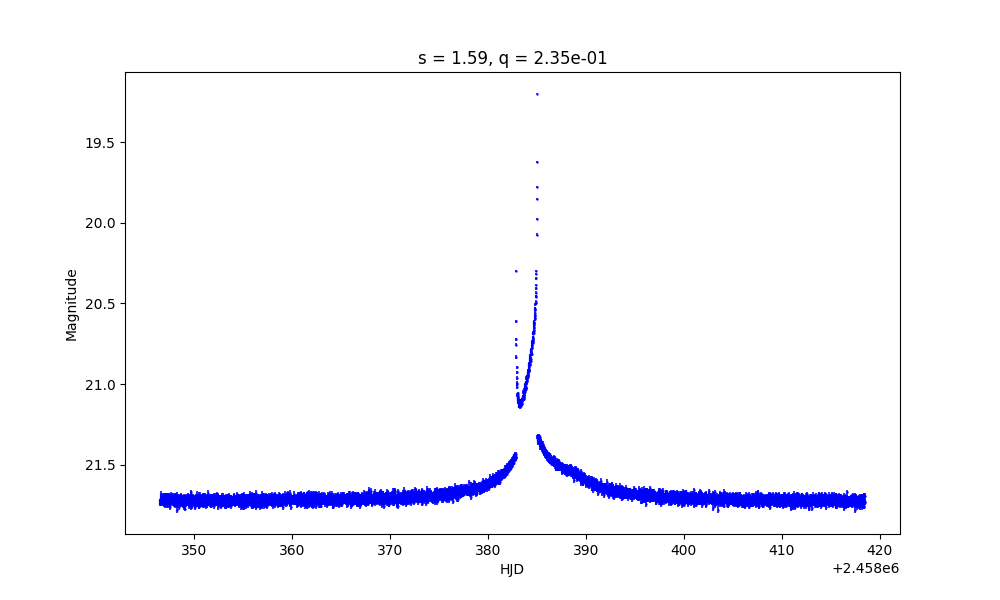

In [61]:
#Plot the light curve
data_bl = pd.read_csv(data_file_bl, sep='\s+', header=None)
data_bl.columns = ['HJD', 'mag', 'err_mag']
data_bl['HJD'] = data_bl['HJD'].astype(float)
data_bl['mag'] = data_bl['mag'].astype(float)
data_bl['err_mag'] = data_bl['err_mag'].astype(float)

#crop data to t_0 - 3*t_E to t_0 + 3*t_E
data_bl = data_bl[(data_bl['HJD'] >= t_0 - 3*t_E) & (data_bl['HJD'] <= t_0 + 3*t_E)]
#Plot the light curve with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(data_bl['HJD'], data_bl['mag'], yerr=data_bl['err_mag'], fmt='o', c='blue', alpha=0.8, markersize=0.8)
plt.xlabel('HJD')
plt.ylabel('Magnitude')
plt.title(f's = {s:.2f}, q = {q:.2e}')
#invert the y-axis
plt.gca().invert_yaxis()
plt.savefig('dc1_071_binlens.png', dpi=300)
plt.show()

In [57]:
#save the light curve and params
np.savetxt('dc1_071_binlens.txt', data_bl)
params = [t_0, u_0, t_E, rho, piE, s, q, alpha]
np.savetxt('dc1_071_binlens_params.txt', params, header='t_0, u_0, t_E, rho, piE, s, q, alpha')



8? 16? 22? 23?? 27 ??
28? 32? 33? 41??
